In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer


In [23]:
df = pd.read_csv("/content/healthcare-dataset-stroke-data.csv")
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [24]:
# Drop the 'id' column as it is not needed for the analysis
df = df.drop('id', axis=1)
display(df.head())

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


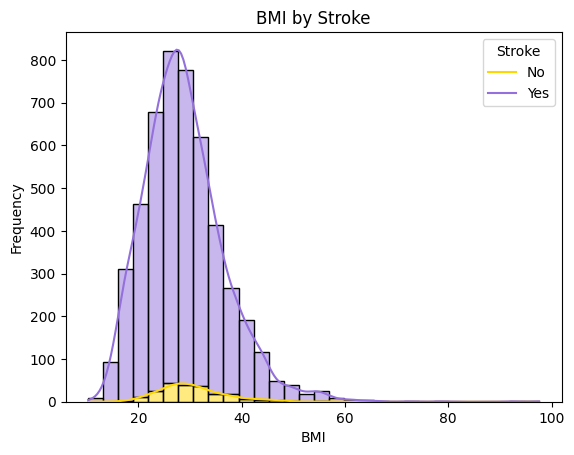

In [25]:

color = ['mediumpurple', 'gold']
sns.histplot(data=df, x='bmi', bins=30, kde=True, hue='stroke', palette= color, multiple='stack')
plt.title('BMI by Stroke')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.legend(title='Stroke', labels=['No', 'Yes'])
plt.show()

#  EDA

In [26]:
df.info()

df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   object 
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   object 
 5   work_type          5110 non-null   object 
 6   Residence_type     5110 non-null   object 
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   object 
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 439.3+ KB


,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201
smoking_status,0


We see that BMI has some missing data

In [27]:
impute = SimpleImputer(strategy='mean')

df['bmi'] = impute.fit_transform(df[['bmi']])
print(df.isna().sum())
df.info()

gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   object 
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   object 
 5   work_type          5110 non-null   object 
 6   Residence_type     5110 non-null   object 
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                5110 non-null   float64
 9   smoking_status     5110 non-null   object 
 10  stroke             5110 non-null   int64  
dty

In [28]:
categorical_cols = ['gender', 'work_type', 'Residence_type', 'smoking_status', 'ever_married']

# Check if categorical columns still exist in the DataFrame
cols_to_encode = [col for col in categorical_cols if col in df.columns]

if cols_to_encode:
    print(f"Encoding columns: {cols_to_encode}")
    df = pd.get_dummies(df, columns=cols_to_encode, drop_first=True, dtype=int)
    display(df.head())
else:
    print("Categorical columns have already been encoded.")
    display(df.head())

Encoding columns: ['gender', 'work_type', 'Residence_type', 'smoking_status', 'ever_married']


,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,gender_Other,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,ever_married_Yes
0,67.0,0,1,228.69,36.600000,1,1,0,0,1,0,0,1,1,0,0,1
1,61.0,0,0,202.21,28.893237,1,0,0,0,0,1,0,0,0,1,0,1
2,80.0,0,1,105.92,32.500000,1,1,0,0,1,0,0,0,0,1,0,1
3,49.0,0,0,171.23,34.400000,1,0,0,0,1,0,0,1,0,0,1,1
4,79.0,1,0,174.12,24.000000,1,0,0,0,0,1,0,0,0,1,0,1


### Analyze the distribution of numerical features

/tmp/ipython-input-4251124237.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=df, x=col, kde=True, bins=30, palette='viridis')


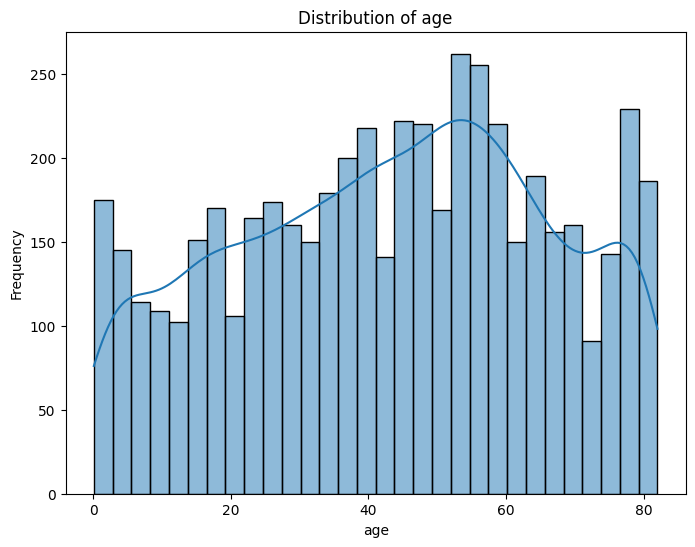

/tmp/ipython-input-4251124237.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=df, x=col, kde=True, bins=30, palette='viridis')


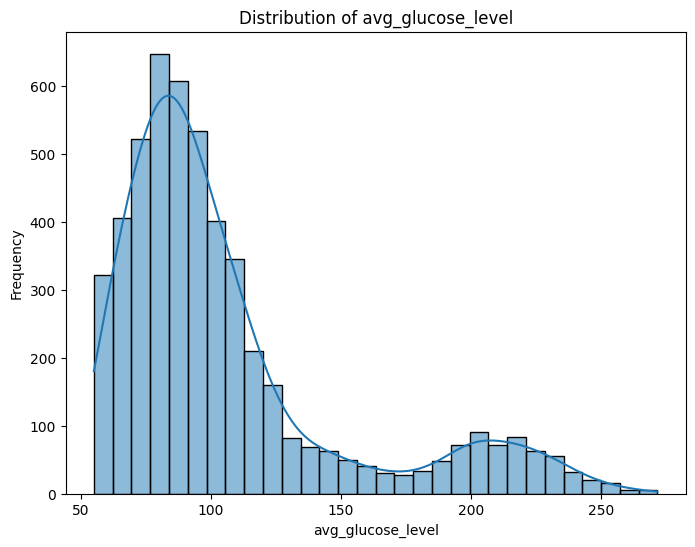

/tmp/ipython-input-4251124237.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=df, x=col, kde=True, bins=30, palette='viridis')


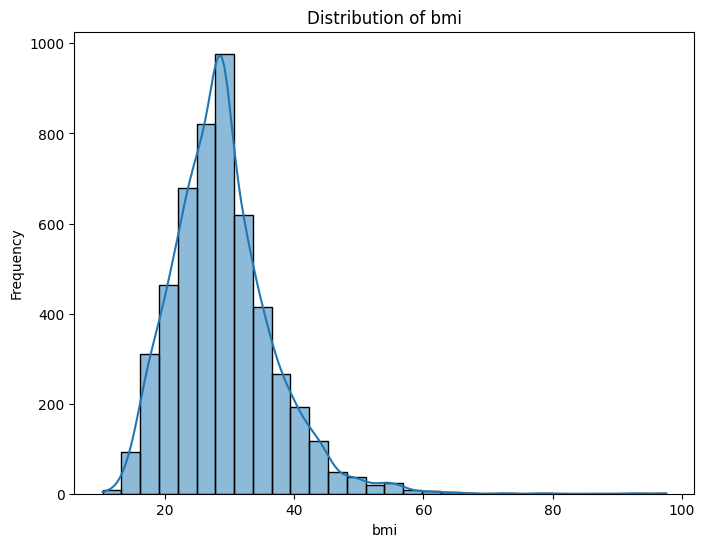

In [29]:
numerical_cols = ['age', 'avg_glucose_level', 'bmi']

for col in numerical_cols:
    plt.figure(figsize=(8, 6))
    sns.histplot(data=df, x=col, kde=True, bins=30, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

### Analyze the relationship between features and the target variable

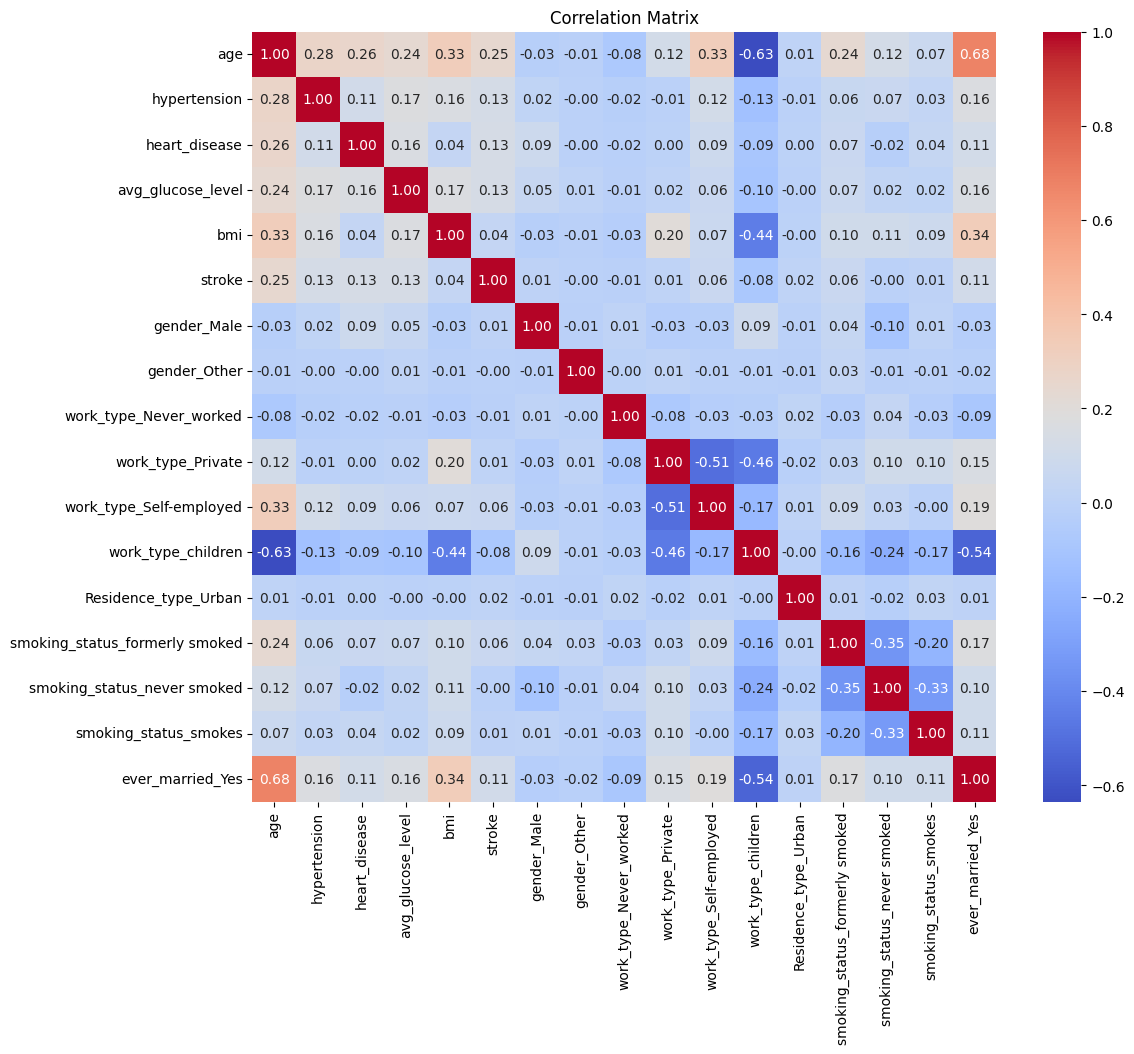

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,gender_Other,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,ever_married_Yes
age,1.000000,0.276398,0.263796,0.238171,0.325942,0.245257,-0.027623,-0.010659,-0.078653,0.116534,0.327989,-0.634215,0.014180,0.236897,0.119307,0.073133,0.679125
hypertension,0.276398,1.000000,0.108306,0.174474,0.160189,0.127904,0.021275,-0.004597,-0.021608,-0.005413,0.115442,-0.129506,-0.007913,0.058853,0.065063,0.031240,0.164243
heart_disease,0.263796,0.108306,1.000000,0.161857,0.038899,0.134914,0.085717,-0.003343,-0.015712,0.000027,0.086760,-0.091634,0.003092,0.066804,-0.021856,0.044049,0.114644
avg_glucose_level,0.238171,0.174474,0.161857,1.000000,0.168751,0.131945,0.054580,0.011489,-0.014675,0.016588,0.062694,-0.102250,-0.004946,0.068111,0.023885,0.017646,0.155068
bmi,0.325942,0.160189,0.038899,0.168751,1.000000,0.038947,-0.025464,-0.011802,-0.028600,0.203884,0.070822,-0.442843,-0.000120,0.104257,0.106220,0.085579,0.335705
stroke,0.245257,0.127904,0.134914,0.131945,0.038947,1.000000,0.009117,-0.003166,-0.014882,0.011888,0.062168,-0.083869,0.015458,0.064556,-0.004129,0.008939,0.108340
gender_Male,-0.027623,0.021275,0.085717,0.054580,-0.025464,0.009117,1.000000,-0.011757,0.011496,-0.032639,-0.025971,0.089283,-0.005937,0.042738,-0.098813,0.011477,-0.029936
gender_Other,-0.010659,-0.004597,-0.003343,0.011489,-0.011802,-0.003166,-0.011757,1.000000,-0.000920,0.012092,-0.006112,-0.005514,-0.014217,0.030568,-0.010728,-0.005978,-0.019327
work_type_Never_worked,-0.078653,-0.021608,-0.015712,-0.014675,-0.028600,-0.014882,0.011496,-0.000920,1.000000,-0.076081,-0.028728,-0.025915,0.022859,-0.030095,0.036238,-0.028099,-0.090838
work_type_Private,0.116534,-0.005413,0.000027,0.016588,0.203884,0.011888,-0.032639,0.012092,-0.076081,1.000000,-0.505475,-0.455992,-0.018173,0.025526,0.104860,0.100025,0.153830


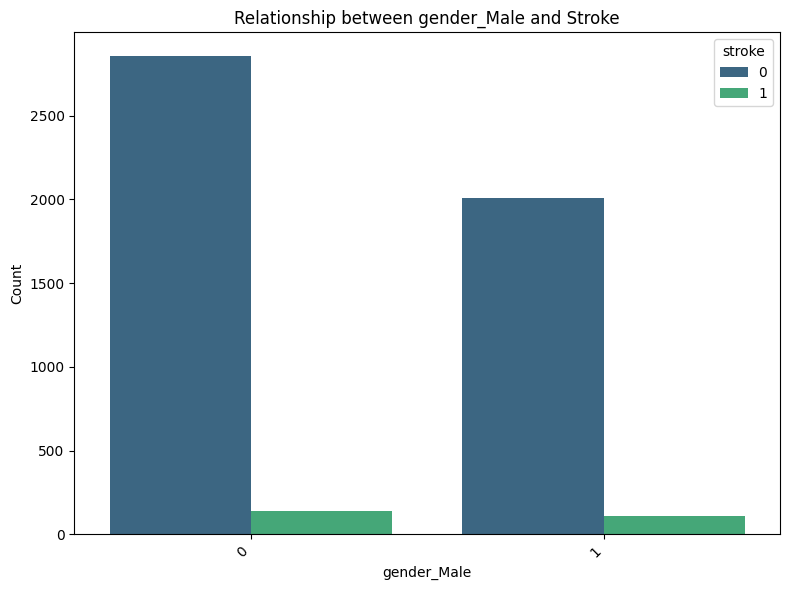

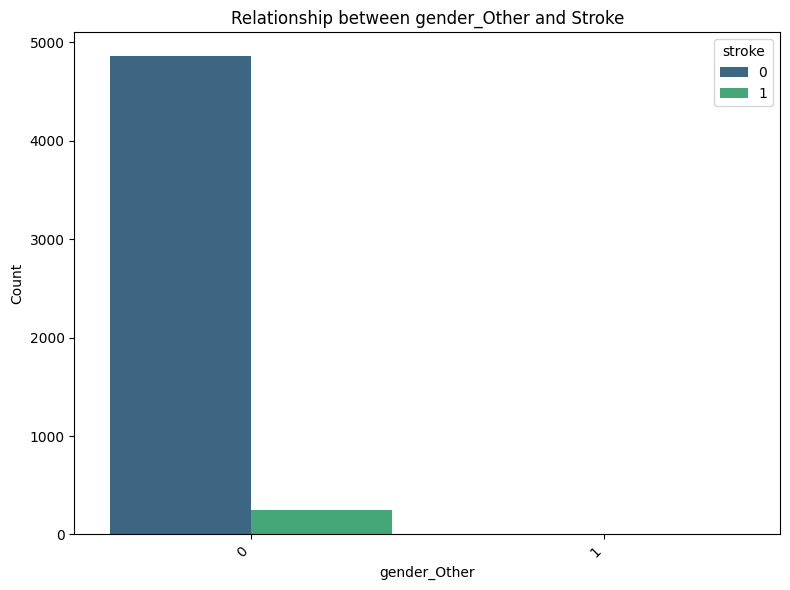

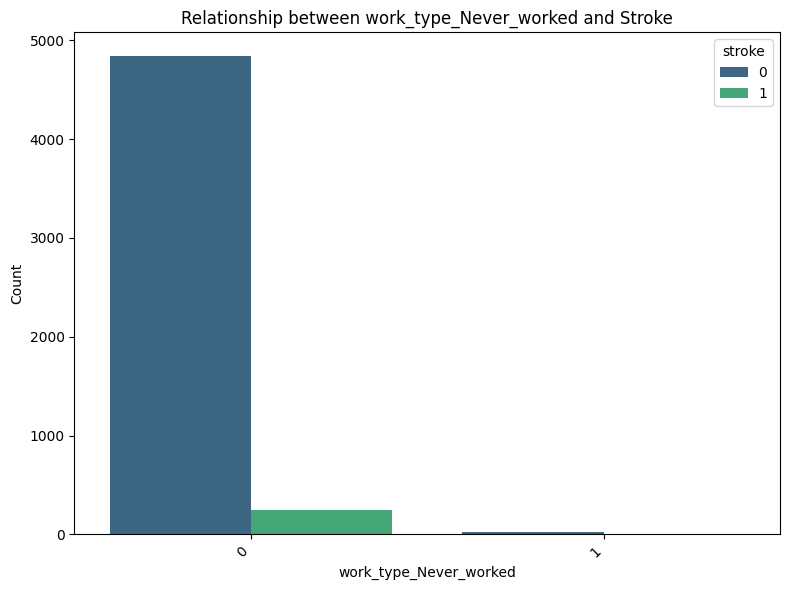

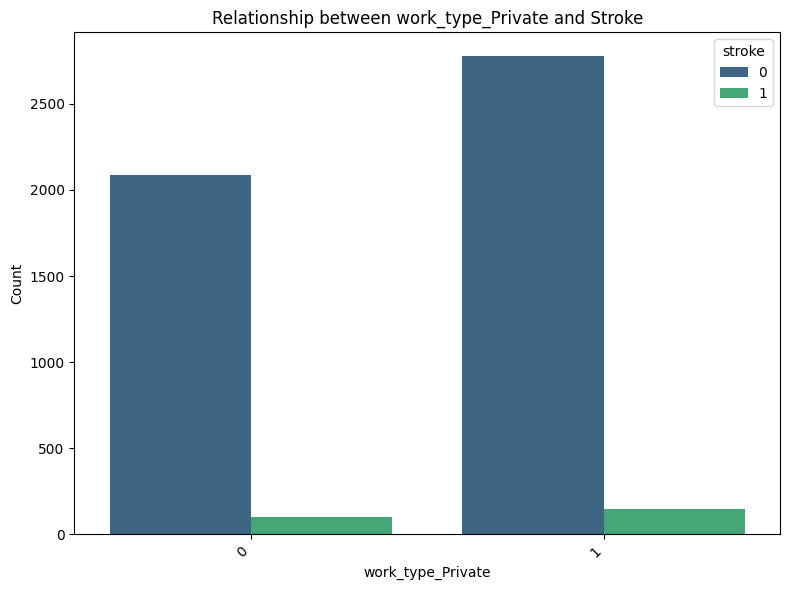

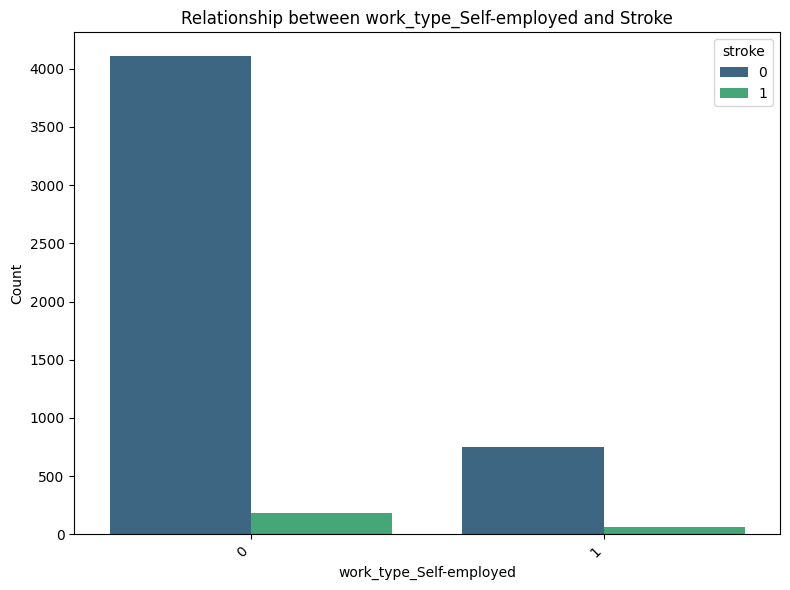

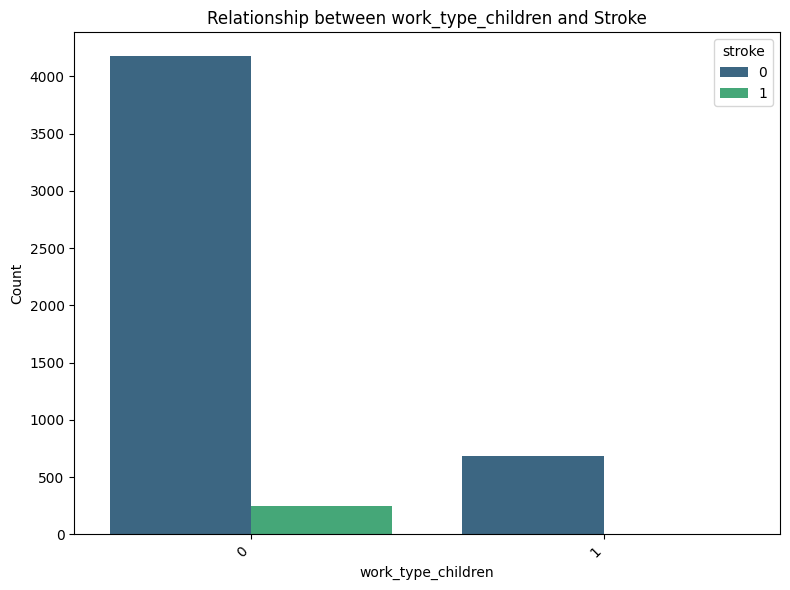

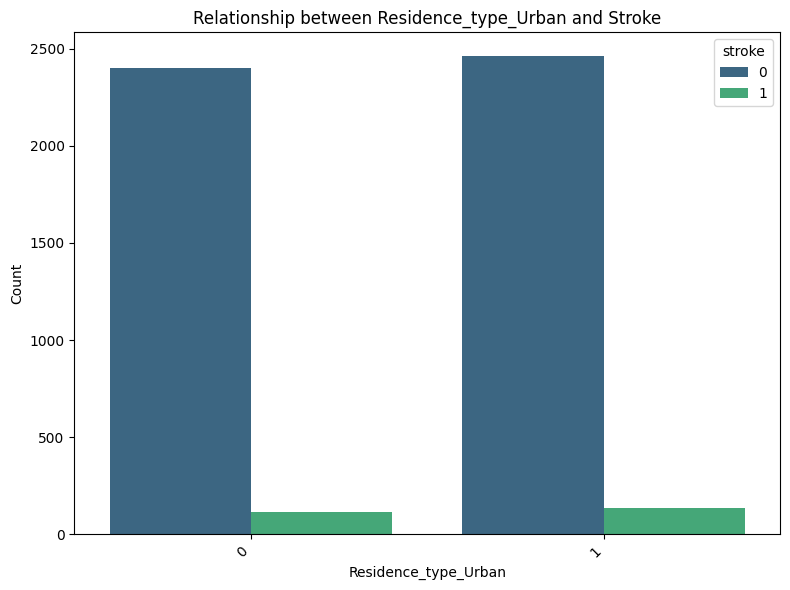

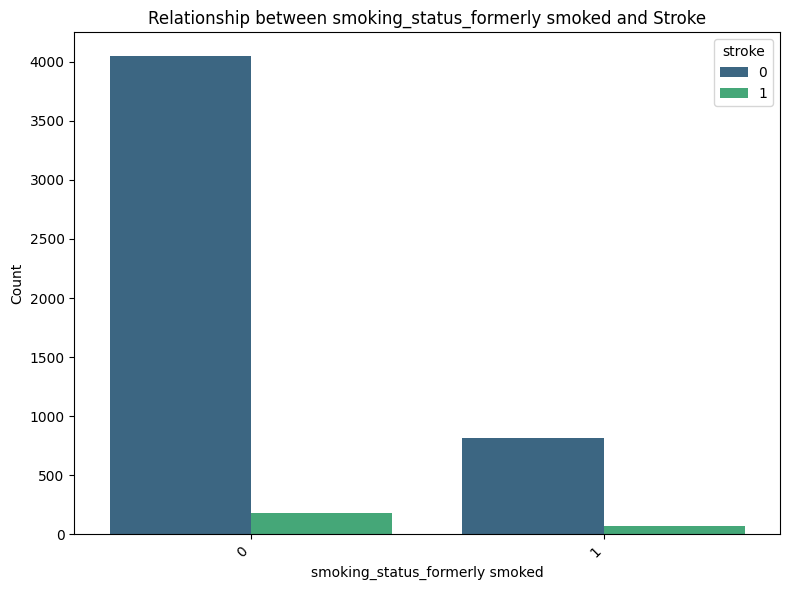

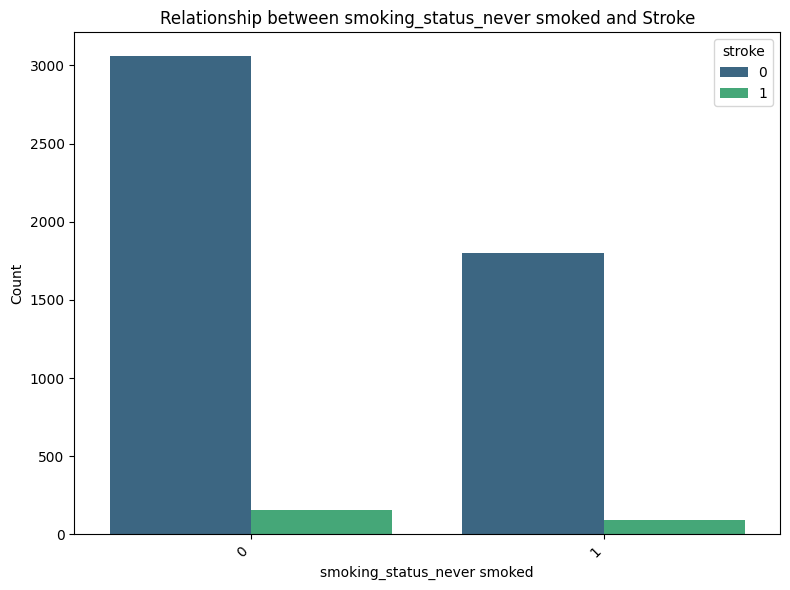

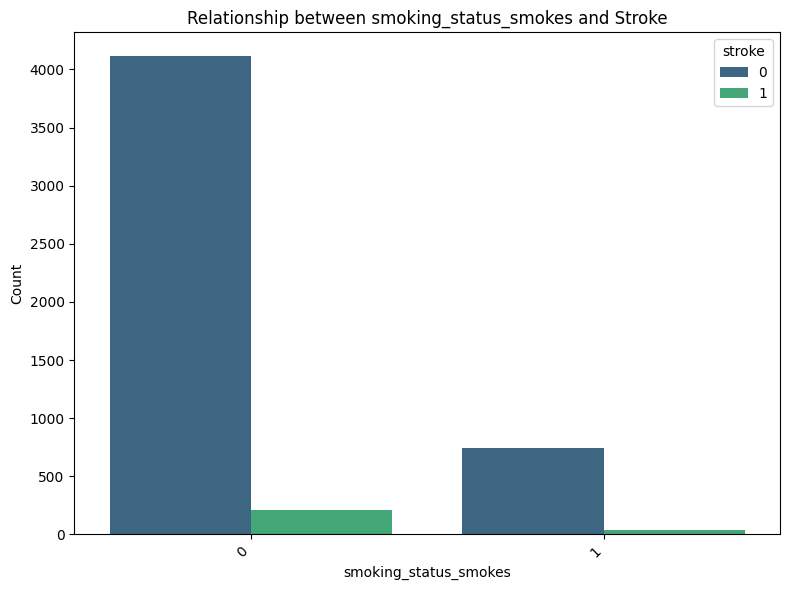

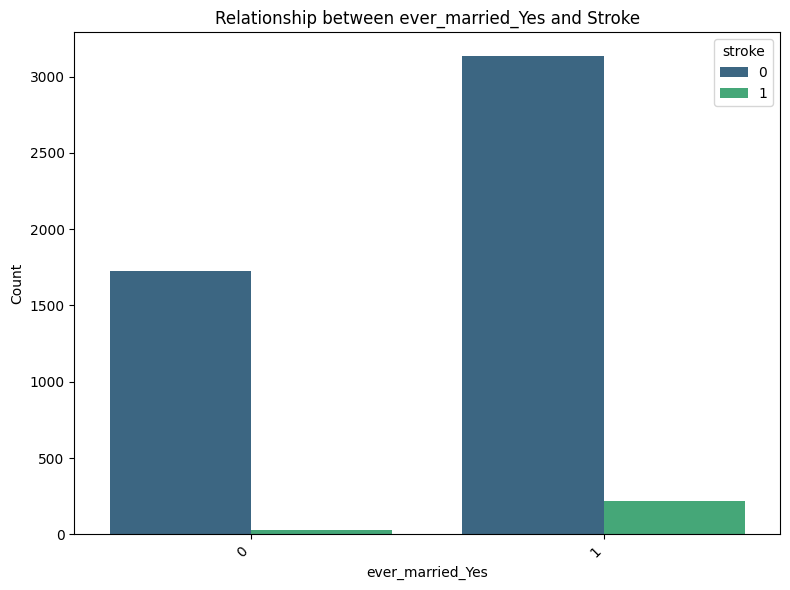

In [30]:
# Analyze correlation matrix for numerical features
correlation_matrix = df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()
display(correlation_matrix)

# Analyze relationship between categorical features and stroke
categorical_cols_encoded = [col for col in df.columns if any(cat in col for cat in ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status'])]

for col in categorical_cols_encoded:
    plt.figure(figsize=(8, 6))
    sns.countplot(data=df, x=col, hue='stroke', palette='viridis')
    plt.title(f'Relationship between {col} and Stroke')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

### Summary of EDA Findings:

*   The dataset contains information on over 5000 individuals with various health and lifestyle factors and whether they had a stroke.
*   The 'bmi' column had missing values, which were imputed with the mean BMI.
*   Categorical features such as gender, work type, residence type, smoking status, and marital status were successfully one-hot encoded for analysis.
*   **Numerical Feature Distributions:**
    *   'Age' shows a wide distribution, as expected, with a peak in the older age groups.
    *   'Average Glucose Level' has a skewed distribution with a long tail towards higher values.
    *   'BMI' also appears to have a somewhat skewed distribution.
*   **Relationship with Stroke:**
    *   'Age' appears to be a significant factor, with a higher incidence of stroke in older individuals.
    *   'Hypertension' and 'Heart Disease' are positively correlated with stroke, aligning with known medical risk factors.
    *   'Average Glucose Level' shows a positive correlation with stroke, particularly at higher levels.
    *   'BMI' shows a weak positive correlation with stroke.
    *   Among categorical features, being married (`ever_married_Yes`), working in private sector (`work_type_Private`), and being formerly smoked (`smoking_status_formerly smoked`) seem to have a slightly higher proportion of stroke cases compared to their counterparts.
*   **Feature Interactions:**
    *   The interaction plots suggest that older individuals with higher average glucose levels may have an increased risk of stroke.
    *   The box plots exploring interactions indicate that age and average glucose level might interact with work type and hypertension, respectively, to influence stroke risk.

### Conclusions:

Based on this EDA, several factors appear to be associated with an increased risk of stroke in this dataset, including older age, presence of hypertension and heart disease, higher average glucose levels, and potentially certain work types, marital status, and smoking habits. BMI shows a weaker association compared to other factors.

These findings provide valuable insights for building a predictive model for stroke and highlight the important features to consider. Further analysis, such as feature selection and model building, can now be pursued based on these observations.

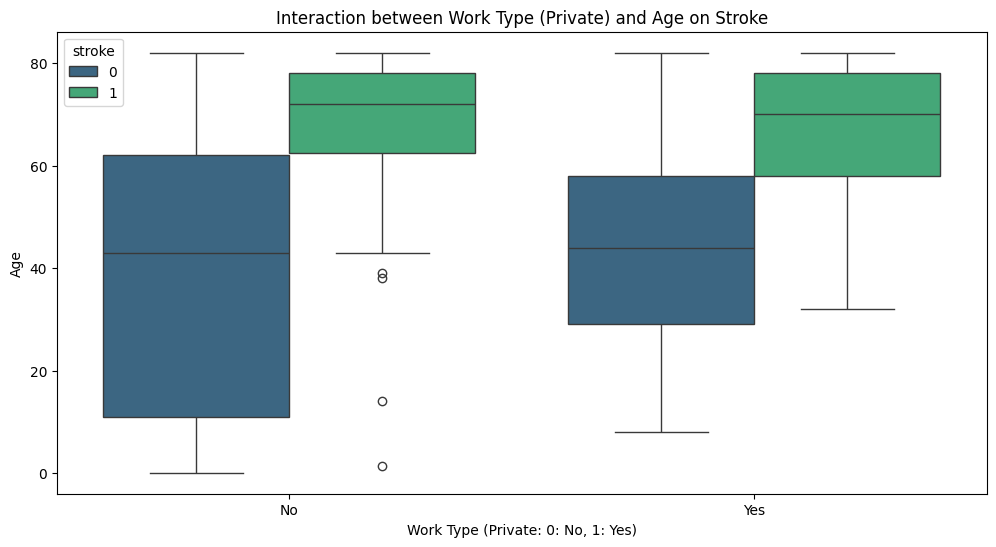

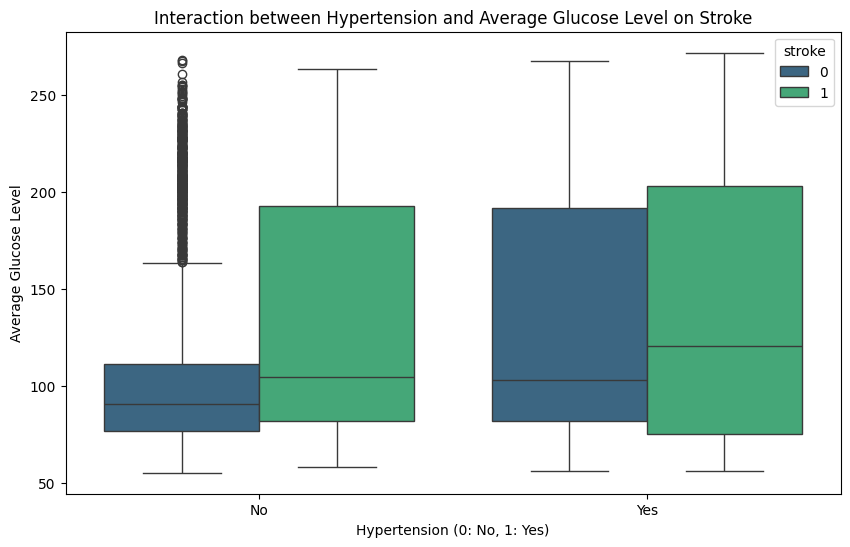

In [31]:
# Example: Interaction between age and work type on stroke
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='work_type_Private', y='age', hue='stroke', palette='viridis')
plt.title('Interaction between Work Type (Private) and Age on Stroke')
plt.xlabel('Work Type (Private: 0: No, 1: Yes)')
plt.ylabel('Age')
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()

# Example: Interaction between average glucose level and hypertension on stroke
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='hypertension', y='avg_glucose_level', hue='stroke', palette='viridis')
plt.title('Interaction between Hypertension and Average Glucose Level on Stroke')
plt.xlabel('Hypertension (0: No, 1: Yes)')
plt.ylabel('Average Glucose Level')
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()

### Analyze feature interactions

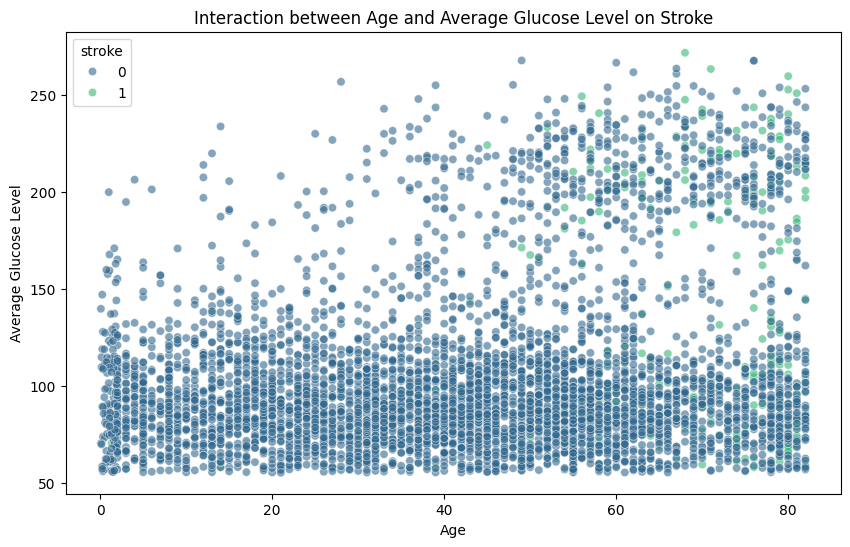

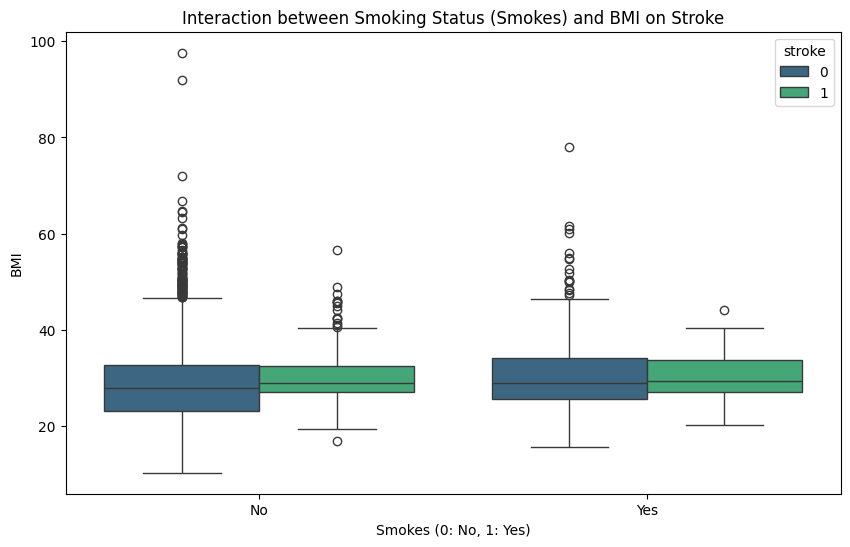

In [32]:
# Example: Interaction between age and average glucose level on stroke
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='age', y='avg_glucose_level', hue='stroke', palette='viridis', alpha=0.6)
plt.title('Interaction between Age and Average Glucose Level on Stroke')
plt.xlabel('Age')
plt.ylabel('Average Glucose Level')
plt.show()

# Example: Interaction between BMI and smoking status on stroke
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='smoking_status_smokes', y='bmi', hue='stroke', palette='viridis')
plt.title('Interaction between Smoking Status (Smokes) and BMI on Stroke')
plt.xlabel('Smokes (0: No, 1: Yes)')
plt.ylabel('BMI')
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()